# QAOA FOR FINANCE

### IMPORT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
from itertools import product 
from functools import reduce

import sys

from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from scripts.snp import SNP
from scripts.baskets import get, BASKETS, config

### GLOBAL PARAMS

In [2]:
np.random.seed(42)

### DATA

In [3]:
anti = pd.read_parquet("../data/anti.parquet")
mag7 = pd.read_parquet("../data/mag7.parquet")
quantum = pd.read_parquet("../data/quantum.parquet")
quantum_big = pd.read_parquet("../data/quantum_big.parquet")

dfs = [anti, mag7, quantum, quantum_big]

df = pd.concat(dfs, axis=1).sort_index()

print(df.head(2))

Ticker            XOM        DAL        NEM         JPM        AAPL  \
Date                                                                  
2023-01-03  95.434204  31.554611  45.624825  124.292603  122.982712   
2023-01-04  95.711967  33.277008  47.400856  125.451637  124.251190   

Ticker            MSFT      GOOGL       AMZN  IONQ   RGTI  QBTS  QUBT  \
Date                                                                    
2023-01-03  233.452789  88.389458  85.820000  3.46  0.728  1.44  1.52   
2023-01-04  223.240829  87.357986  85.139999  3.61  0.814  1.29  1.55   

Ticker             IBM         HON         ACN       NVDA  
Date                                                       
2023-01-03  125.228752  188.414520  255.968201  14.299910  
2023-01-04  126.157707  184.669144  255.096786  14.733454  


### VISUALS


16 assets, 751 1d obs
Ticker     Ann.Ret   Ann.Vol    Sharpe
XOM          7.75%    22.66%     0.342
DAL         26.27%    38.45%     0.683
NEM         26.92%    37.06%     0.726
JPM         31.81%    23.07%     1.379
AAPL        26.74%    25.46%     1.050
MSFT        24.66%    23.13%     1.066
GOOGL       42.55%    30.24%     1.407
AMZN        33.49%    31.86%     1.051
IONQ        86.43%   100.05%     0.864
RGTI       115.15%   143.41%     0.803
QBTS        97.54%   146.41%     0.666
QUBT        64.62%   139.01%     0.465
IBM         29.15%    23.70%     1.230
HON          1.22%    20.59%     0.059
ACN          1.51%    25.14%     0.060
NVDA        86.48%    49.64%     1.742
✓ saved → plots\eda\all_prices.pdf


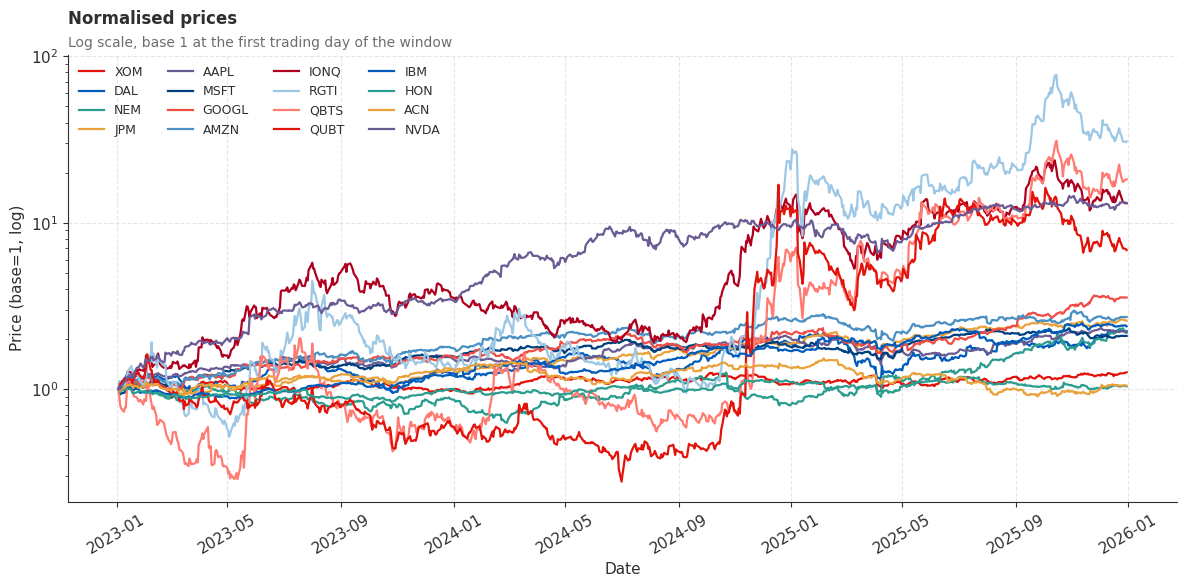

✓ saved → plots\eda\all_returns.pdf


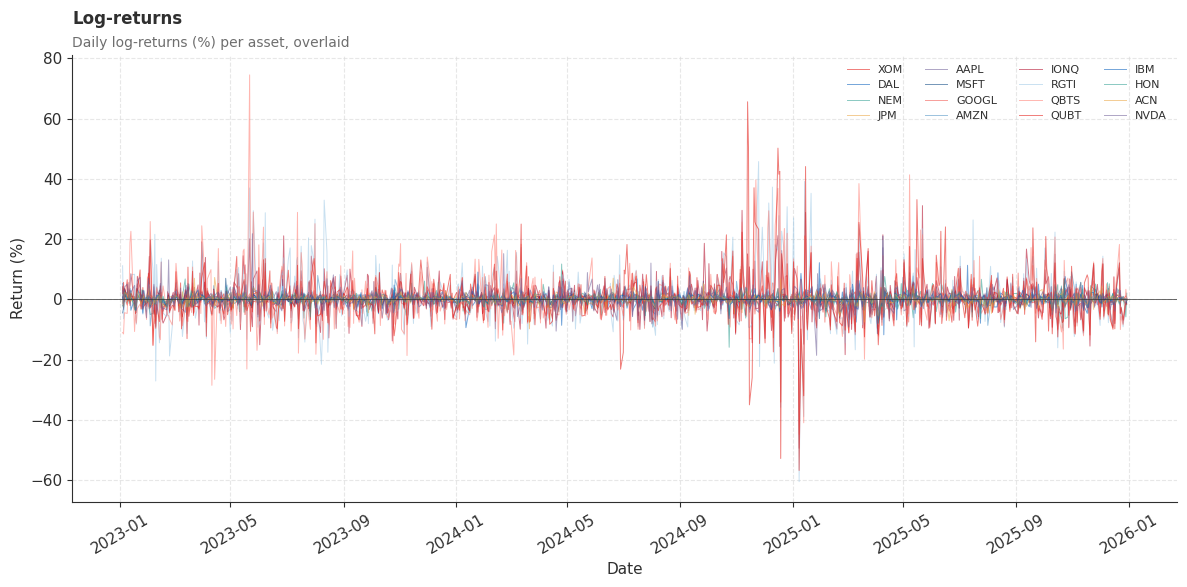

✓ saved → plots\eda\all_rolling_vol.pdf


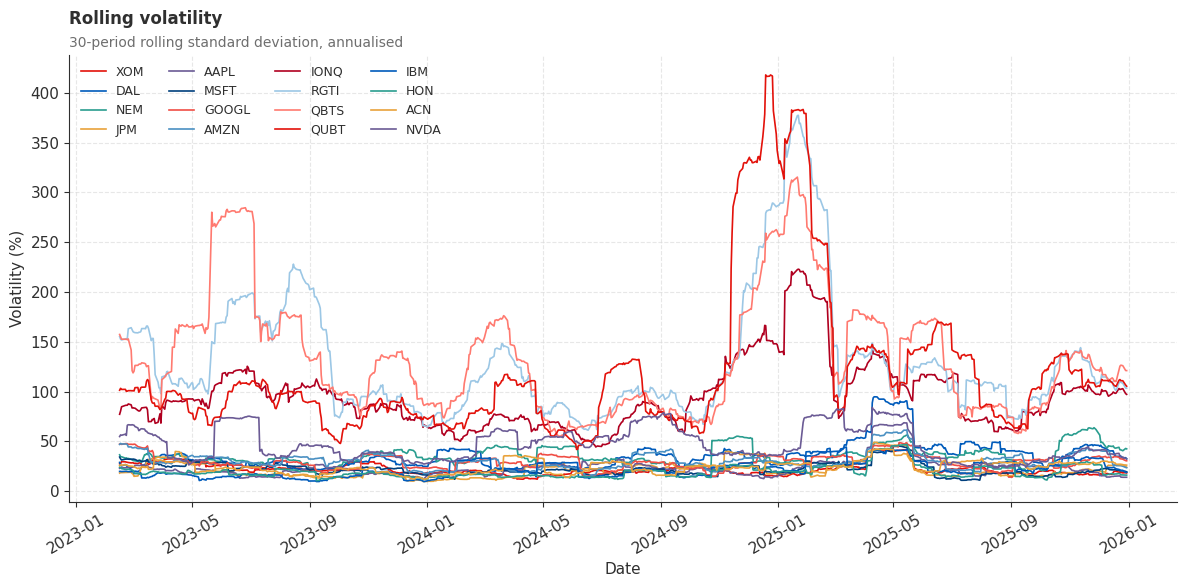

✓ saved → plots\eda\all_histogram.pdf


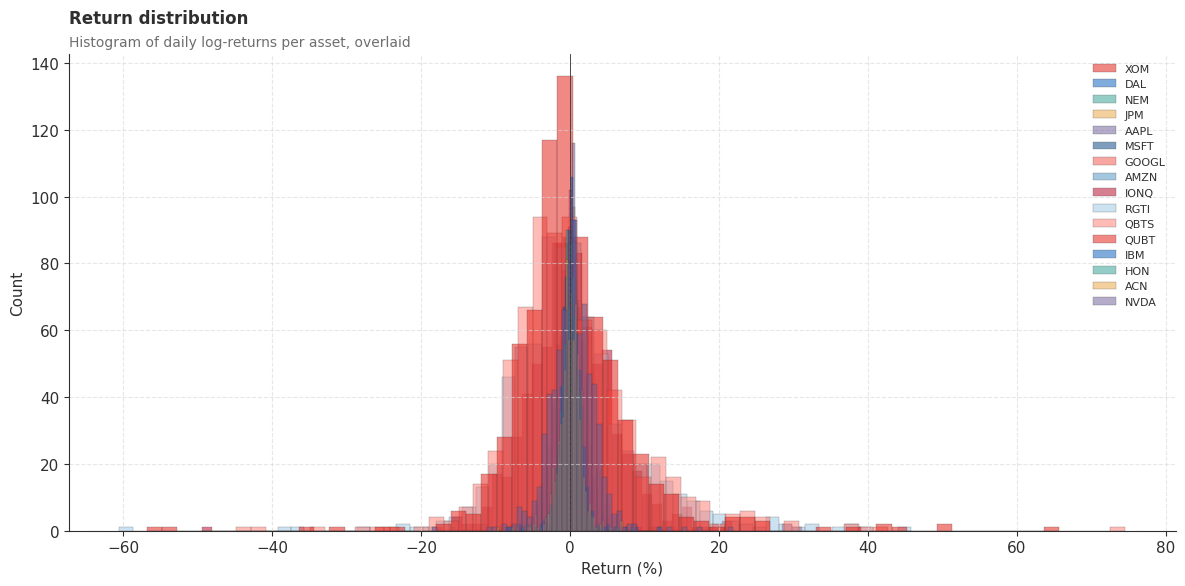

✓ saved → plots\eda\all_correlation.pdf


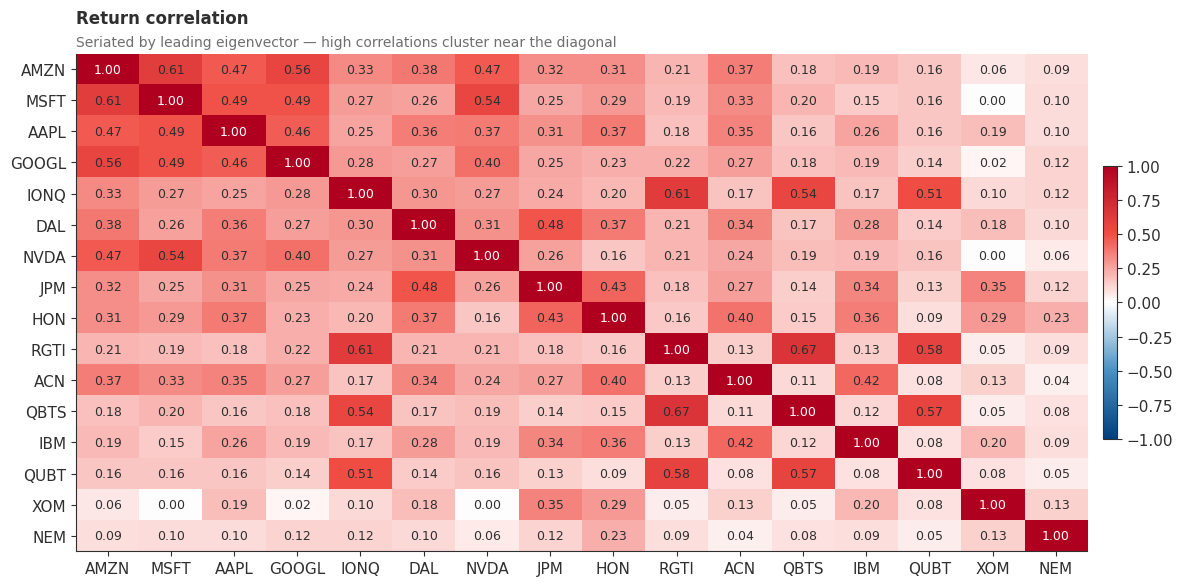

✓ saved → plots\eda\all_risk_return.pdf


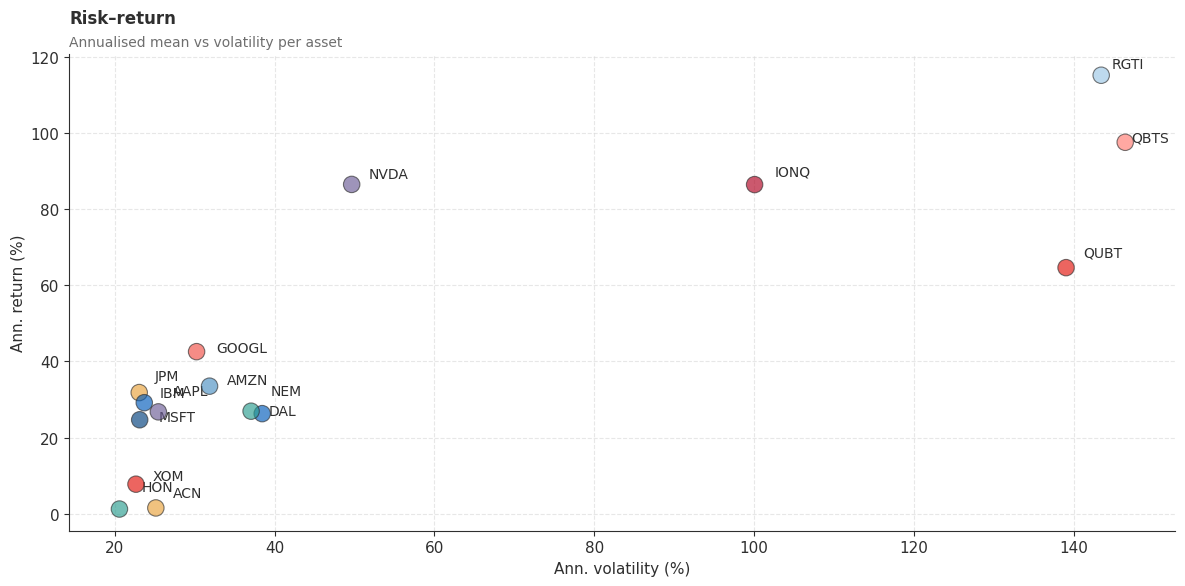

In [4]:
# All tickers overlaid - 6 separate (12, 6) panels
snp = SNP(list(df.columns), df.index.min(), df.index.max())
snp.prices = df

snp.summary()
snp.plot(save=True, name="all", individual=True, figsize=(12, 6))